#### NX-414: Brain-like computation and intelligence
Notebook prepared by Alessandro Marin Vargas

# Week 8 - Mini projects (Predicting neural activity)

The objectives of the mini project are:
- Learn how to predict neural activity using linear regression from images and from neural network layers.
- Quantify the goodness of the model
- Compare the results across the network layers and between trained/random neural network
- Predict the neural activity using a neural network in a data-driven approach

Specifically, here you will use the data from the following [paper](https://www.jneurosci.org/content/jneuro/35/39/13402.full.pdf). The behavioral experiment consisted in showing to non-human primates some images while recording the neural activity with multielectrode arrays from the inferior temporal (IT) cortex. Here, the neural activity and the images are already pre-processed and you will have available the images and the corresponding average firing rate (between 70 and 170 ms) per each neuron.

In [1]:
import sys
sys.path.append('./../')
!{sys.executable} -m pip install gdown h5py

You should consider upgrading via the '/home/vvoigt/Documents/NX/NX-414-Project/venv/bin/python -m pip install --upgrade pip' command.


In [2]:
import utils
import matplotlib.pyplot as plt
import numpy as np
import gdown
url = "https://drive.google.com/file/d/1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS/view?usp=share_link"
output = "IT_data.h5"
gdown.download(url, output, quiet=False, fuzzy=True)


Downloading...
From (original): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS
From (redirected): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS&confirm=t&uuid=e3acc76a-84ea-428a-8506-9329b6a2f467
To: /home/vvoigt/IT_data.h5
100%|███████████████████████████████████████████████████████████████████████████████████████████| 384M/384M [00:04<00:00, 90.2MB/s]


'IT_data.h5'

### Load the data

In [3]:
###copy pasted from utils, since import did somehow not work...
import h5py
import os

import matplotlib.pyplot as plt
import numpy as np
def load_it_data(path_to_data):
    """ Load IT data

    Args:
        path_to_data (str): Path to the data

    Returns:
        np.array (x6): Stimulus train/val/test; objects list train/val/test; spikes train/val
    """

    datafile = h5py.File(os.path.join(path_to_data,'IT_data.h5'), 'r')

    stimulus_train = datafile['stimulus_train'][()]
    spikes_train = datafile['spikes_train'][()]
    objects_train = datafile['object_train'][()]
    
    stimulus_val = datafile['stimulus_val'][()]
    spikes_val = datafile['spikes_val'][()]
    objects_val = datafile['object_val'][()]
    
    stimulus_test = datafile['stimulus_test'][()]
    objects_test = datafile['object_test'][()]

    ### Decode back object type to latin
    objects_train = [obj_tmp.decode("latin-1") for obj_tmp in objects_train]
    objects_val = [obj_tmp.decode("latin-1") for obj_tmp in objects_val]
    objects_test = [obj_tmp.decode("latin-1") for obj_tmp in objects_test]

    return stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val


def visualize_img(stimulus,objects,stim_idx):
    """Visualize image given the stimulus and corresponding index and the object name.

    Args:
        stimulus (array of float): Stimulus containing all the images
        objects (list of str): Object list containing all the names
        stim_idx (int): Index of the stimulus to plot
    """    
    normalize_mean=[0.485, 0.456, 0.406]
    normalize_std=[0.229, 0.224, 0.225]

    img_tmp = np.transpose(stimulus[stim_idx],[1,2,0])

    ### Go back from normalization
    img_tmp = (img_tmp*normalize_std + normalize_mean) * 255

    plt.figure()
    plt.imshow(img_tmp.astype(np.uint8),cmap='gray')
    plt.title(str(objects[stim_idx]))
    plt.show()
    return

In [4]:
path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)


In [5]:
n_stimulus, n_channels, img_size, _ = stimulus_train.shape
_, n_neurons = spikes_train.shape
print('The dataset contains {} stimuli and {} IT neurons'.format(n_stimulus,n_neurons))
print('Each stimulus have {} channgels (RGB)'.format(n_channels))
print('The size of the image is {}x{}'.format(img_size,img_size))

The dataset contains 2592 stimuli and 168 IT neurons
Each stimulus have 3 channgels (RGB)
The size of the image is 224x224


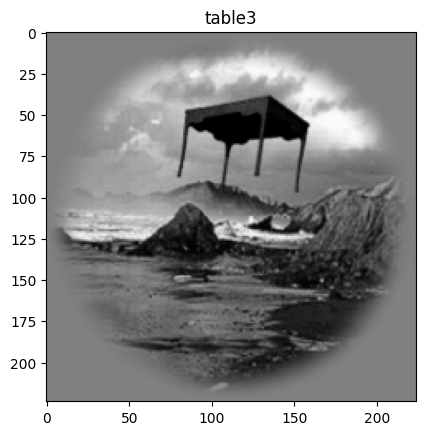

In [6]:
stim_idx = 1

visualize_img(stimulus_train,objects_train,stim_idx)

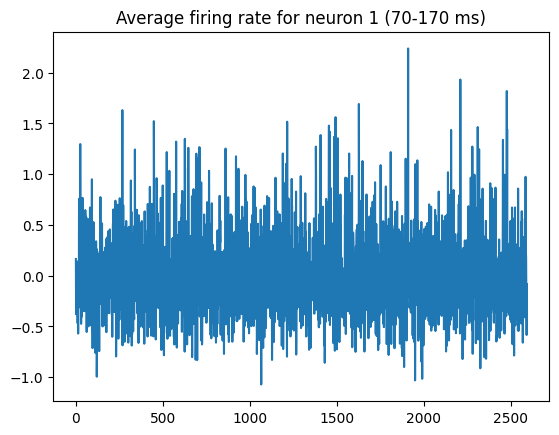

In [7]:
neuron_idx = 1

plt.figure()
plt.title('Average firing rate for neuron {} (70-170 ms)'.format(neuron_idx))
plt.plot(spikes_train[:,neuron_idx])

# Challenge: Develop the most accurate model for predicting IT neural activity.

Throughout the mini-projects, you have acquired knowledge on predicting neural activity through both task-driven and data-driven approaches. You are now free to explore both approaches to create the most effective model for predicting neural activity. Here are some suggestions to help guide your exploration:
- Optimize your current models by adjusting hyperparameters and implementing different regularizations.
- Utilize different pretrained models.
- Employ a pretrained neural network and finetune it for predicting the neural activity.
- Train a neural network for object recognition while simultaneously predicting neural activity.
- ...

Please note that all models will be tested using the same type of linear regression.

### EVALUATION

You have until midnight of 07/05/25 to submit your mini-projects. Please upload a .zip file on Moodle containing your code and, specifically, the following:

- A one-page report (Report.pdf) detailing your investigation, including figures and model comparisons.
- A script (test.py) or notebook (test.ipynb) in which you show an example of your best model's usage. Please include instructions on loading the model and making neural predictions on the validation set. If necessary, include the checkpoint of your model in the .zip file.

Best of luck!

In [8]:
### Here your code

### First approach: using a pretrained model, namely VGG16

In [9]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr
from tqdm import tqdm

In [10]:
from torchvision import transforms
import torch

# Convert numpy arrays to torch tensors
stimulus_train_torch = torch.tensor(stimulus_train).float()
stimulus_val_torch = torch.tensor(stimulus_val).float()

# Define normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Apply normalization
stim_train_torch = torch.stack([normalize(img) for img in stimulus_train_torch])
stim_val_torch = torch.stack([normalize(img) for img in stimulus_val_torch])

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader, TensorDataset

# Define the model (fine-tuning VGG16)
class VGG16_Finetune(nn.Module):
    def __init__(self, pretrained_model):
        super(VGG16_Finetune, self).__init__()
        # Take all layers except the classifier (final fully connected layers)
        self.features = pretrained_model.features
        # Replace the classifier to output the neural activity (number of neurons to predict)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),  # VGG16 has a 512 * 7 * 7 output from the convolutional layers
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, spikes_train.shape[1])  # Number of neurons (based on spikes_train)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  # Flatten the output to pass it into the fully connected layers
        x = self.classifier(x)
        return x

# Load the pretrained VGG16 model
vgg16_model = models.vgg16(pretrained=True)

# Fine-tune the model (we'll modify the classifier part)
model_finetuned = VGG16_Finetune(vgg16_model)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_finetuned.to(device)

# DataLoader: Convert data to tensors and create DataLoader for batching
def create_dataloader(stimulus, spikes, batch_size):
    # Convert to TensorDataset and DataLoader for batching
    dataset = TensorDataset(stimulus, spikes)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

# Define batch size (adjust this based on GPU memory)
batch_size_train = 64  # For training
batch_size_val = 32    # For validation (can be smaller for evaluation)

# Convert your stimuli and spikes to tensors (if not already)
stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)

# Create dataloaders
train_dataloader = create_dataloader(stimulus_train_tensor, spikes_train_tensor, batch_size_train)
val_dataloader = create_dataloader(stimulus_val_tensor, spikes_val_tensor, batch_size_val)

# Define the loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.Adam(model_finetuned.parameters(), lr=1e-4)  # Adam optimizer

/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
# Number of epochs to train
num_epochs = 10

# Training loop
for epoch in range(num_epochs):
    model_finetuned.train()  # Set the model to training mode
    running_loss = 0.0
    for batch_input, batch_labels in train_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)

        optimizer.zero_grad()  # Zero the gradients
        outputs = model_finetuned(batch_input)  # Forward pass
        loss = criterion(outputs, batch_labels)  # Compute the loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update the weights

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_dataloader):.4f}")


Epoch [1/10], Loss: 0.1265
Epoch [2/10], Loss: 0.0970
Epoch [3/10], Loss: 0.0810
Epoch [4/10], Loss: 0.0683
Epoch [5/10], Loss: 0.0574
Epoch [6/10], Loss: 0.0484
Epoch [7/10], Loss: 0.0410
Epoch [8/10], Loss: 0.0358
Epoch [9/10], Loss: 0.0318
Epoch [10/10], Loss: 0.0287


In [13]:
# Evaluate the model on the validation set
model_finetuned.eval()  # Set the model to evaluation mode
with torch.no_grad():
    val_outputs = []
    val_labels = []
    for batch_input, batch_labels in val_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
        outputs = model_finetuned(batch_input)
        val_outputs.append(outputs.cpu().numpy())
        val_labels.append(batch_labels.cpu().numpy())

    val_outputs = np.concatenate(val_outputs, axis=0)
    val_labels = np.concatenate(val_labels, axis=0)

    # Compute Pearson Correlation
    pearson_corr = np.corrcoef(val_outputs.flatten(), val_labels.flatten())[0, 1]
    print(f"Pearson Correlation: {pearson_corr:.4f}")

    # Compute Explained Variance Score
    evs = explained_variance_score(val_labels, val_outputs)
    print(f"Explained Variance Score: {evs:.4f}")

Pearson Correlation: 0.6904
Explained Variance Score: 0.4005


make plot for variation of neural prediction across layers.

In [14]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook


conv_layer_indices = {
    "conv1_1": 0, "conv1_2": 2,
    "conv2_1": 5, "conv2_2": 7,
    "conv3_1": 10, "conv3_2": 12, "conv3_3": 14,
    "conv4_1": 17, "conv4_2": 19, "conv4_3": 21,
    "conv5_1": 24, "conv5_2": 26, "conv5_3": 28,
}

layer_names = list(conv_layer_indices.keys())

for name, idx in conv_layer_indices.items():
    model_finetuned.features[idx].register_forward_hook(get_activation(name))



In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import explained_variance_score
import numpy as np
import torch
from sklearn.linear_model import Ridge


model_finetuned.eval()

features_val = {name: [] for name in layer_names}
features_train = {name: [] for name in layer_names}
targets_val = []
targets_train = []

# TRAIN
activations = {}

for images, spike_targets in train_dataloader:
    with torch.no_grad():
        images = images.to(device)
        spike_targets = spike_targets.to(device)
        _ = model_finetuned(images)

        for name in layer_names:
            act = activations[name]  # shape: (B, C, H, W)
            pooled = torch.nn.functional.adaptive_avg_pool2d(act, (4, 4))  # (B, C, 4, 4)
            flat = pooled.view(act.size(0), -1)  # (B, C * 4 * 4)
            features_train[name].append(flat.cpu())

        targets_train.append(spike_targets.cpu())

# VAL
for images, spike_targets in val_dataloader:
    with torch.no_grad():
        images = images.to(device)
        spike_targets = spike_targets.to(device)
        _ = model_finetuned(images)

        for name in layer_names:
            act = activations[name]
            pooled = torch.nn.functional.adaptive_avg_pool2d(act, (4, 4))  # Add this line
            flat = pooled.view(act.size(0), -1)                            # Same as in training
            features_val[name].append(flat.cpu())

        targets_val.append(spike_targets.cpu())

# Finalize
for name in layer_names:
    features_train[name] = torch.cat(features_train[name]).numpy()
    features_val[name] = torch.cat(features_val[name]).numpy()
targets_train = torch.cat(targets_train).numpy()
targets_val = torch.cat(targets_val).numpy()

# Evaluate
r2_scores = []
pearson_rs = []

for name in layer_names:
    X_train = features_train[name]
    X_val = features_val[name]
    
    from sklearn.decomposition import PCA
    pca = PCA(n_components=100).fit(X_train)
    X_train = pca.transform(X_train)
    X_val = pca.transform(X_val)

    reg = Ridge(alpha=1.0)
    reg.fit(X_train, targets_train)

    preds = reg.predict(X_val)
    r2 = explained_variance_score(targets_val, preds)
    corr = np.corrcoef(targets_val.ravel(), preds.ravel())[0, 1]
    
    r2_scores.append(r2)
    pearson_rs.append(corr)

    print(f"{name}: R² = {r2:.3f}, Pearson r = {corr:.3f}")


conv1_1: R² = 0.169, Pearson r = 0.445
conv1_2: R² = 0.202, Pearson r = 0.480
conv2_1: R² = 0.240, Pearson r = 0.524
conv2_2: R² = 0.262, Pearson r = 0.546
conv3_1: R² = 0.267, Pearson r = 0.551
conv3_2: R² = 0.290, Pearson r = 0.572
conv3_3: R² = 0.324, Pearson r = 0.610
conv4_1: R² = 0.353, Pearson r = 0.637
conv4_2: R² = 0.360, Pearson r = 0.644
conv4_3: R² = 0.372, Pearson r = 0.657
conv5_1: R² = 0.377, Pearson r = 0.663
conv5_2: R² = 0.383, Pearson r = 0.669
conv5_3: R² = 0.383, Pearson r = 0.669


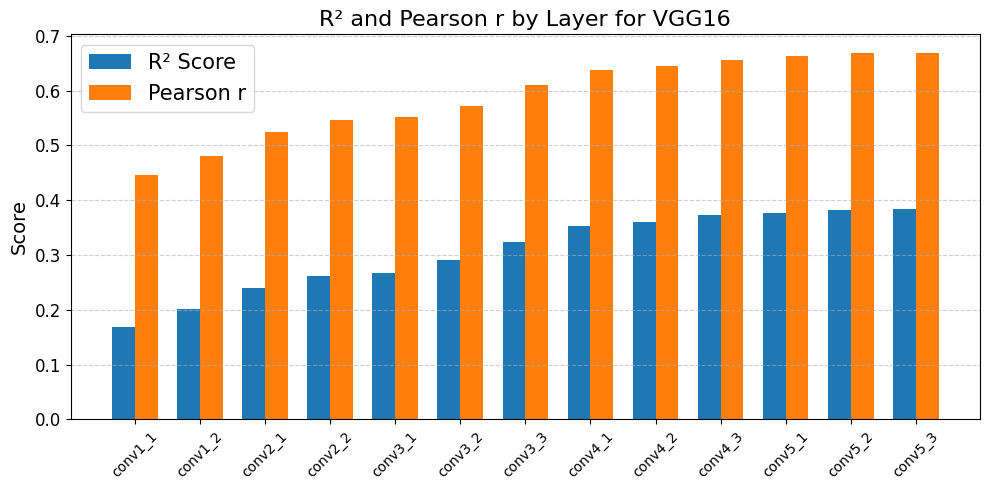

In [16]:
# Plot
x = np.arange(len(layer_names))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 5))
bar1 = ax1.bar(x - width/2, r2_scores, width, label='R² Score')
bar2 = ax1.bar(x + width/2, pearson_rs, width, label='Pearson r')


# Set axis labels and title with larger font size
ax1.set_ylabel('Score', fontsize=14)
ax1.set_title('R² and Pearson r by Layer for VGG16', fontsize=16)

# Set x-ticks and labels with larger font size
ax1.set_xticks(x)
ax1.set_xticklabels(layer_names, rotation=45, fontsize=12)

# Use tick_params to set font size for the ticks
ax1.tick_params(axis='x', labelsize=10)  # Adjust the x-tick label font size
ax1.tick_params(axis='y', labelsize=12) 

# Set legend with larger font size
ax1.legend(fontsize=15)

# Layout adjustments and grid
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Save the figure with high DPI
plt.savefig("variation_across_layers.png", dpi=300)

# Show the plot
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].


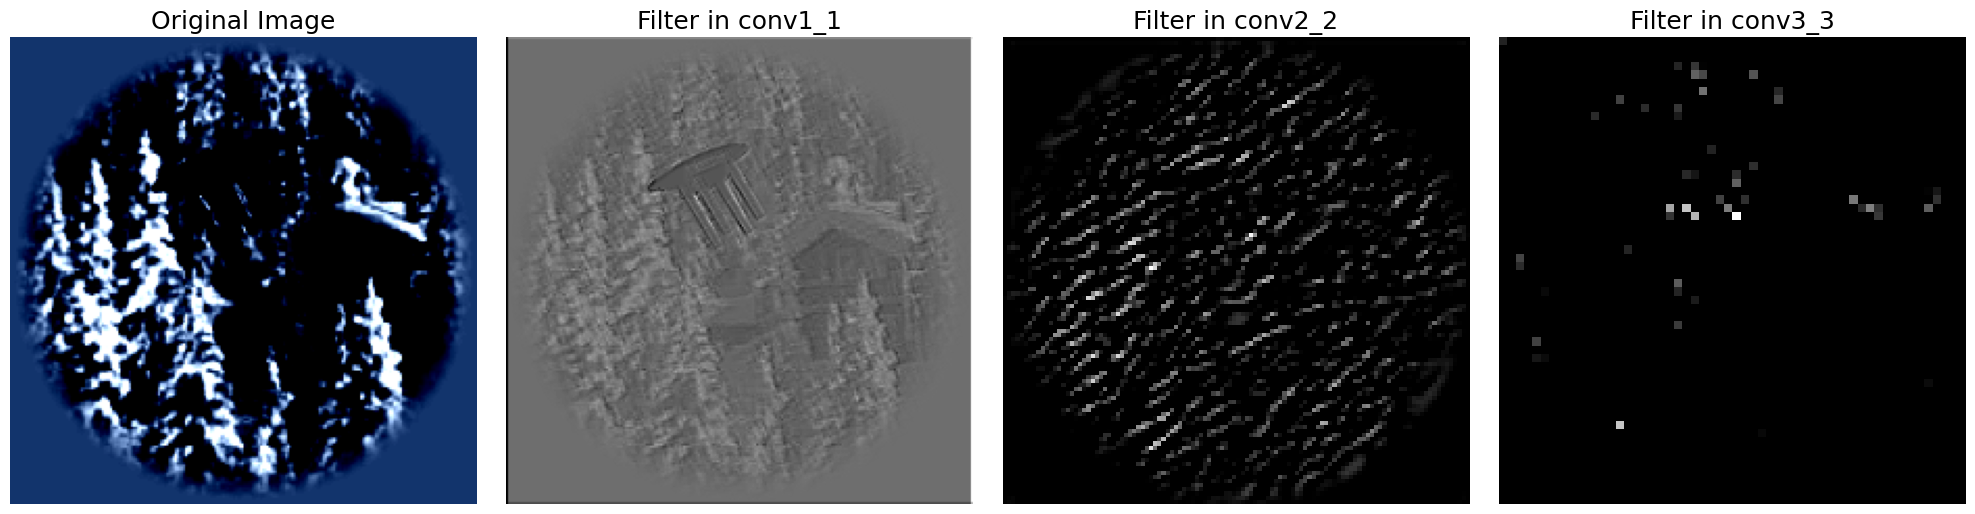

In [17]:
import matplotlib.pyplot as plt

# Assuming 'activations' is already populated with the activation outputs
layer_names_plt2 = ['conv1_1', 'conv2_2', 'conv3_3']  # Add all desired layer names here

# Create a figure with 1 row and len(layer_names) + 1 columns (1 for the original image)
fig, axes = plt.subplots(1, len(layer_names_plt2) + 1, figsize=(20, 5))

# Plot original image in the first subplot
axes[0].imshow(images[0].cpu().numpy().transpose(1, 2, 0))  # Assuming 'images' is the input batch
axes[0].set_title('Original Image', fontsize=18)
axes[0].axis('off')

# Loop over the layers and plot the first filter of each activation output
for idx, layer_name in enumerate(layer_names_plt2):
    activation_output = activations[layer_name]  # Get the activation for this layer
    filter_img = activation_output[0, 0].cpu().numpy()  # First image in batch, first filter
    axes[idx + 1].imshow(filter_img, cmap='gray')
    axes[idx + 1].set_title(f'Filter in {layer_name}', fontsize=18)
    axes[idx + 1].axis('off')

plt.tight_layout()
#plt.savefig("image_across_layers.png", dpi=300)
plt.show()


try hyperparameter tuning

In [21]:
import optuna

# Define the objective function for Optuna
def objective(trial):
    # Hyperparameter tuning: sample values for batch size, learning rate, etc.
    batch_size_train = trial.suggest_int("batch_size_train", 16, 128, step=16)  # Batch size
    batch_size_val = trial.suggest_int("batch_size_val", 16, 128, step=16)  # Batch size for validation
    lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)  # Learning rate (log scale)
    
    # Convert your stimuli and spikes to tensors (if not already)
    stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
    stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
    spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
    spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)
    
    # Create dataloaders
    train_dataloader = create_dataloader(stimulus_train_tensor, spikes_train_tensor, batch_size_train)
    val_dataloader = create_dataloader(stimulus_val_tensor, spikes_val_tensor, batch_size_val)
    
    # Load the pretrained VGG16 model
    vgg16_model = models.vgg16(pretrained=True)
    model_finetuned = VGG16_Finetune(vgg16_model)
    
    # Move model to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_finetuned.to(device)
    
    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_finetuned.parameters(), lr=lr)
    
    # Training loop
    num_epochs = 10
    for epoch in range(num_epochs):
        print(f"at epoch {epoch}")
        model_finetuned.train()
        running_loss = 0.0
        for batch_input, batch_labels in train_dataloader:
            batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = model_finetuned(batch_input)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

    # Evaluate the model on the validation set
    model_finetuned.eval()
    with torch.no_grad():
        val_outputs = []
        val_labels = []
        for batch_input, batch_labels in val_dataloader:
            batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
            outputs = model_finetuned(batch_input)
            val_outputs.append(outputs.cpu().numpy())
            val_labels.append(batch_labels.cpu().numpy())

        val_outputs = np.concatenate(val_outputs, axis=0)
        val_labels = np.concatenate(val_labels, axis=0)

        # Compute Pearson Correlation
        pearson_corr = np.corrcoef(val_outputs.flatten(), val_labels.flatten())[0, 1]
        evs = explained_variance_score(val_labels, val_outputs)

    return pearson_corr  # Return the metric to optimize (e.g., explained variance score)

# Hyperparameter tuning using Optuna
study = optuna.create_study(direction="maximize")  # We want to maximize explained variance score
study.optimize(objective, n_trials=20)  # Run 20 trials

# Output the best hyperparameters
print("Best hyperparameters:", study.best_params)
print("Best value (Explained Variance Score):", study.best_value)

[I 2025-05-05 09:39:55,664] A new study created in memory with name: no-name-601e482d-bd19-4e96-b175-6804e22ffcd9
/tmp/2622788/ipykernel_1256404/3573248439.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)  # Learning rate (log scale)
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=V

at epoch 0
at epoch 1
at epoch 2
at epoch 3
at epoch 4
at epoch 5
at epoch 6
at epoch 7
at epoch 8
at epoch 9


[I 2025-05-05 09:41:57,603] Trial 0 finished with value: 0.6900833798827667 and parameters: {'batch_size_train': 64, 'batch_size_val': 48, 'lr': 0.00023184191149142728}. Best is trial 0 with value: 0.6900833798827667.
/tmp/2622788/ipykernel_1256404/3573248439.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)  # Learning rate (log scale)
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecat

at epoch 0
at epoch 1
at epoch 2
at epoch 3
at epoch 4
at epoch 5
at epoch 6
at epoch 7
at epoch 8
at epoch 9


[I 2025-05-05 09:44:18,096] Trial 1 finished with value: -0.009047886825856987 and parameters: {'batch_size_train': 16, 'batch_size_val': 80, 'lr': 0.004909621093712458}. Best is trial 0 with value: 0.6900833798827667.
/tmp/2622788/ipykernel_1256404/3573248439.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)  # Learning rate (log scale)
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are depreca

...

at epoch 0
at epoch 1
at epoch 2
at epoch 3
at epoch 4
at epoch 5
at epoch 6
at epoch 7
at epoch 8
at epoch 9


[I 2025-05-05 10:19:34,945] Trial 18 finished with value: 0.6960374839469741 and parameters: {'batch_size_train': 48, 'batch_size_val': 16, 'lr': 2.168073687880846e-05}. Best is trial 6 with value: 0.7082297985779397.
/tmp/2622788/ipykernel_1256404/3573248439.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)  # Learning rate (log scale)
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecat

at epoch 0
at epoch 1
at epoch 2
at epoch 3
at epoch 4
at epoch 5
at epoch 6
at epoch 7
at epoch 8
at epoch 9


[I 2025-05-05 10:21:35,495] Trial 19 finished with value: -0.019717642615093005 and parameters: {'batch_size_train': 96, 'batch_size_val': 32, 'lr': 0.000894375729728981}. Best is trial 6 with value: 0.7082297985779397.


Best hyperparameters: {'batch_size_train': 16, 'batch_size_val': 16, 'lr': 0.00010019976995777299}
Best value (Explained Variance Score): 0.7082297985779397


In [ ]:
# Now evaluate the best model.
best_params = study.best_params
batch_size_train = best_params["batch_size_train"]
batch_size_val = best_params["batch_size_val"]
learning_rate = best_params["lr"]

stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)

def create_dataloader(stimulus, spikes, batch_size):
    dataset = TensorDataset(stimulus, spikes)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

train_dataloader = create_dataloader(stimulus_train_tensor, spikes_train_tensor, batch_size_train)
val_dataloader = create_dataloader(stimulus_val_tensor, spikes_val_tensor, batch_size_val)

# Step 3: Load model and optimizer
vgg16_model = models.vgg16(pretrained=True)
model_finetuned = VGG16_Finetune(vgg16_model)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_finetuned.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_finetuned.parameters(), lr=learning_rate)

# Step 4: Retrain model
num_epochs = 10
for epoch in range(num_epochs):
    model_finetuned.train()
    running_loss = 0.0
    for batch_input, batch_labels in train_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        outputs = model_finetuned(batch_input)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_dataloader):.4f}")

# Step 5: Evaluate
model_finetuned.eval()
with torch.no_grad():
    val_outputs = []
    val_labels = []
    for batch_input, batch_labels in val_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
        outputs = model_finetuned(batch_input)
        val_outputs.append(outputs.cpu().numpy())
        val_labels.append(batch_labels.cpu().numpy())

    val_outputs = np.concatenate(val_outputs, axis=0)
    val_labels = np.concatenate(val_labels, axis=0)

    # Pearson Correlation
    val_outputs_flat = val_outputs.flatten()
    val_labels_flat = val_labels.flatten()
    if np.std(val_outputs_flat) == 0 or np.std(val_labels_flat) == 0:
        pearson_corr = 0.0
    else:
        pearson_corr, _ = pearsonr(val_outputs_flat, val_labels_flat)
    print(f"Pearson Correlation: {pearson_corr:.4f}")

    # Explained Variance
    evs = explained_variance_score(val_labels, val_outputs)
    print(f"Explained Variance Score: {evs:.4f}")


Epoch [1/10], Loss: 0.1138
Epoch [2/10], Loss: 0.0869
Epoch [3/10], Loss: 0.0731
Epoch [4/10], Loss: 0.0624
Epoch [5/10], Loss: 0.0528
Epoch [6/10], Loss: 0.0450
Epoch [7/10], Loss: 0.0392
Epoch [8/10], Loss: 0.0351
Epoch [9/10], Loss: 0.0309
Epoch [10/10], Loss: 0.0278
Pearson Correlation: 0.7135
Explained Variance Score: 0.4320
